# Supervised Learning — Enhanced Teaching Notebook

This notebook continues from preprocessing and focuses on model training, validation, hyperparameter tuning, metrics, visualizations for bias-variance, and decision-boundary visual aids.


## Notebook structure

1. Imports & load preprocessed Titanic dataset
2. Train / validation / test split (detailed theory)
3. Models: Logistic Regression, Decision Tree, Random Forest, KNN
4. Hyperparameter tuning (GridSearchCV) — explanation + demo
5. Metrics with formulas and confusion matrix derivation
6. Visual aids: confusion matrix diagram, ROC curve, decision boundary (PCA 2D), bias-variance curves
7. Practical tips & exercises


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load and minimal preprocessing (same dataset for continuity)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
print('Dataset ready')

Dataset ready


## 1) Train / Validation / Test split — detailed theory (See Previous Notebook)

plitting your data into **training**, **validation**, and **test** sets is a core best practice in machine learning. This prevents overfitting and enables honest model evaluation by ensuring that your model is not 'tested' on the same data it was 'trained' on.

## Why Three-Way Split?

- **Training Set:** Used to fit the model’s parameters. The model learns patterns from this data.
- **Validation Set:** Used during training to fine-tune hyperparameters (settings that configure the model, like learning rate or tree depth) and to select among different model types. This set gives a checkpoint; the model doesn’t learn from it, but you use its performance to guide your choices.
- **Test Set:** Used only at the *end*, for final, unbiased assessment of the model’s accuracy and generalization to new data. The model has not seen this data at all during training or tuning.

**Typical split ratios:** 60–80% training, 10–20% validation, 10–20% test.

## Why Not Use Just Training and Test?

If you tune model hyperparameters directly on the test set, your model can overfit to that test data—that is, it “cheats” by tailoring itself to the test examples, and its performance estimate gets artificially high and unreliable for new data. Having a separate validation set allows honest tuning without leaking information from the test set.

## Cross-Validation (k-Fold)

Instead of one fixed validation set, **cross-validation** splits the data into k portions (“folds”), rotates through these, and averages metrics to get a more reliable measure. Each fold acts as a validation set once and as part of the training set k – 1 times. This reduces the variance of our accuracy estimate, and is very useful if your dataset is small.

## Key Points and Benefits

- Splitting into train/validation/test helps produce robust models that generalize well beyond the initial data.
- Validation sets let you optimize and compare models, helping you avoid overfitting.
- Test set provides the final, unbiased metric reflecting expected performance on truly unseen data.
- Cross-validation strengthens the reliability of your results, especially with limited data.

***


In [2]:
# Create stratified splits
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Sizes -> Train:', X_train.shape[0], 'Val:', X_val.shape[0], 'Test:', X_test.shape[0])

Sizes -> Train: 623 Val: 134 Test: 134


## 2) Scaling and preparing data for models

**Teaching note:** Fit scalers on training data only. Use the same scaler to transform validation/test sets to avoid leakage.

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## 3) Train and compare baseline models

We train Logistic Regression, Decision Tree, Random Forest, and KNN with default hyperparameters to get baseline performance.

See Slides for More details about these models

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

for name, m in models.items():
    m.fit(X_train_s, y_train)
    val_acc = m.score(X_val_s, y_val)
    print(f'{name} validation accuracy: {val_acc:.4f}')

Logistic Regression validation accuracy: 0.8582
Decision Tree validation accuracy: 0.7910
Random Forest validation accuracy: 0.8209
KNN validation accuracy: 0.8433


## 4) Hyperparameter tuning — theory + GridSearchCV demo

# Hyperparameter Tuning:

In machine learning, **hyperparameters** are settings you choose before training a model—for example, the number of trees in a Random Forest, or learning rate in gradient boosting. These are not learned from the data, but set externally. The right hyperparameters can dramatically improve your model's performance.

## The Problem

- Models perform differently depending on their hyperparameter values.
- Trying different settings by hand is slow, and may miss the best ones.
- We want to systematically search for the best values, and do it fairly!


## Common Search Methods

### GridSearchCV

- **Grid Search** means trying _every_ combination from a set (or "grid") of hyperparameter values: example, all settings for number of trees × max depth × split criteria, etc.
- For each combination, the model is trained and evaluated (commonly with cross-validation to avoid overfitting).
- **Pros:** Finds the best combination in a small, controlled search space.
- **Cons:** Quickly becomes slow and impractical if you have many hyperparameters or lots of possible values; trains the model many times.


### RandomizedSearchCV

- **Randomized Search** randomly samples a set number of hyperparameter combinations from specified ranges or distributions.
- Instead of exhaustively testing all options, it chooses a "slice" of possibilities.
- **Pros:** Much faster for large grids—sometimes finds excellent settings with less work.
- **Cons:** Might miss the true best if not enough samples are tested, but is usually more practical for deep or wide grids.


## Cross-Validation and Fair Evaluation

Both methods use **cross-validation**: dividing your data into "folds," training the model on part and validating on the other, rotating which fold is used for validation. This helps ensure results aren't accidental—your model doesn't just work "by chance" on one random split.

- **Nested Cross-Validation:** Goes one step further. You use cross-validation to pick hyperparameters, _then_ use a separate cross-validation to assess final performance. This prevents accidental "peeking"—avoiding optimistic bias from tuning hyperparameters on the same folds you use for evaluation.


## Best Practices for Beginners

- **GridSearchCV** is good for small grids and when you want to try every possibility.
- **RandomizedSearchCV** is better for large grids with many options, saving time while still exploring well.
- Always use cross-validation (k-fold) when tuning hyperparameters—never fit or tune using test data!
- For final results (e.g., publishing), use **nested cross-validation** to report honest, unbiased performance.


## Quick Example

Suppose you have a Random Forest, and want to tune `n_estimators` and `max_depth`. GridSearchCV will train models at every pair of settings, while RandomizedSearchCV will train, say, 20 randomly chosen combinations.

**In summary:**

- Hyperparameters = model settings chosen before training.
- GridSearchCV = exhaustive search over a grid.
- RandomizedSearchCV = random sampling from the grid, quicker for large spaces.
- Use cross-validation to avoid overfitting and get reliable performance scores.
- Use nested cross-validation for truly unbiased model assessment.



In [5]:
param_grids = {
    'Logistic Regression': {'C':[0.01,0.1,1,10]},
    'Decision Tree': {'max_depth':[3,5,7,None], 'min_samples_split':[2,5,10]},
    'Random Forest': {'n_estimators':[50,100], 'max_depth':[5,10,None]},
    'KNN': {'n_neighbors':[3,5,7,9]}
}

best_models = {}
for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    best_models[name] = grid.best_estimator_
    print(name, 'best params:', grid.best_params_, 'best CV score:', grid.best_score_)

Logistic Regression best params: {'C': 0.01} best CV score: 0.8073290322580645
Decision Tree best params: {'max_depth': 5, 'min_samples_split': 10} best CV score: 0.8185419354838709
Random Forest best params: {'max_depth': 5, 'n_estimators': 50} best CV score: 0.832941935483871
KNN best params: {'n_neighbors': 7} best CV score: 0.8104774193548387


## 5) Metrics, Confusion Matrix, and formulas

**Confusion matrix:**

```
           Predicted Positive   Predicted Negative
Actual Pos        TP                  FN
Actual Neg        FP                  TN
```

Formulas:
- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 * Precision * Recall / (Precision + Recall)
- ROC-AUC = Area under ROC curve (TPR vs FPR) across thresholds

**Interpretation:**
- Precision matters when FP are costly.
- Recall matters when FN are costly.
- F1 balances both.



Logistic Regression - Test metrics:
Accuracy: 0.7836, Precision: 0.8056, Recall: 0.5686, F1: 0.6667, ROC-AUC: 0.7983


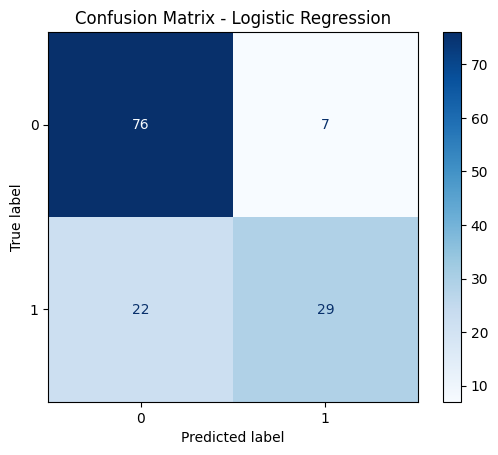


Decision Tree - Test metrics:
Accuracy: 0.7537, Precision: 0.7647, Recall: 0.5098, F1: 0.6118, ROC-AUC: 0.8038


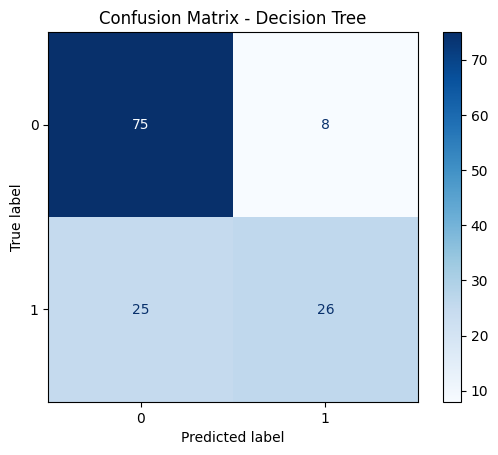


Random Forest - Test metrics:
Accuracy: 0.7687, Precision: 0.7273, Recall: 0.6275, F1: 0.6737, ROC-AUC: 0.8083


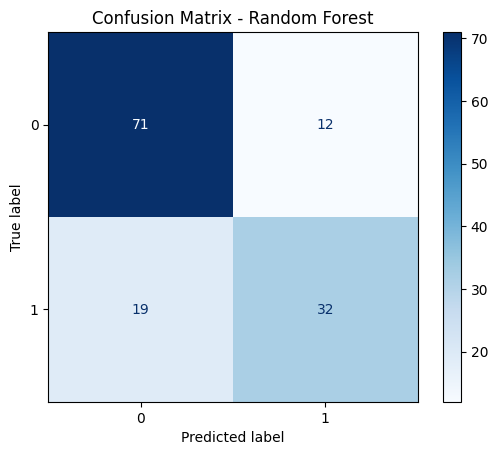


KNN - Test metrics:
Accuracy: 0.7463, Precision: 0.6809, Recall: 0.6275, F1: 0.6531, ROC-AUC: 0.8352


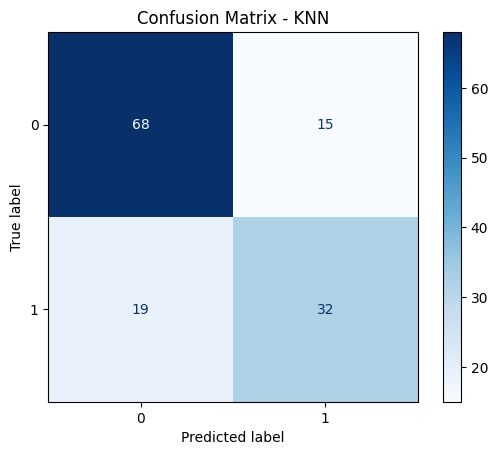

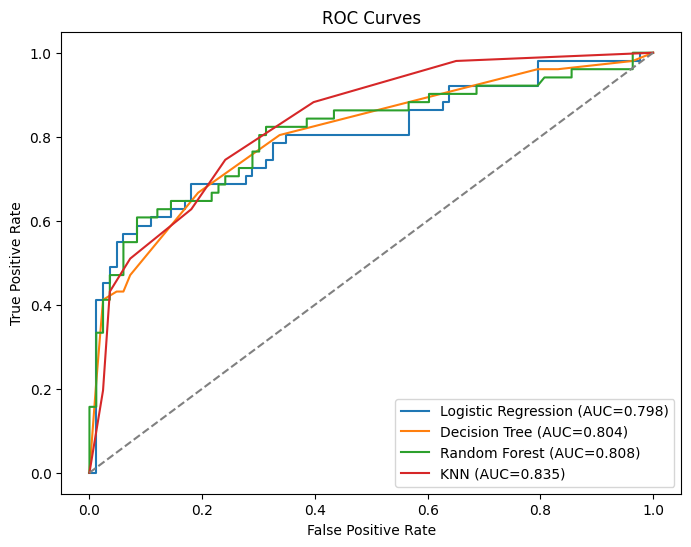

In [6]:
# Evaluate best models on test set and show confusion matrix + ROC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

for name, model in best_models.items():
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:,1] if hasattr(model, 'predict_proba') else model.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"\n{name} - Test metrics:\nAccuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# ROC curves overlay
plt.figure(figsize=(8,6))
for name, model in best_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_s)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Evaluating Models: Test Set, Confusion Matrix, and ROC Curve

Evaluating your machine learning model on the test set is essential for understanding how well it will perform on new, unseen data. This code demonstrates several key steps:

## 1. Metrics for Model Performance

You test each model from `best_models` on the test set and compute:

- **Accuracy**: The fraction of total predictions that were correct. Simple but can be misleading if classes are imbalanced (like most passengers not surviving).
- **Precision**: Of all predicted positives (survivors), how many were correct? Useful when false positives are costly (like predicting a disease that isn’t present).
- **Recall**: Out of all actual positives, how many did your model find? Important when missing a positive is risky (like missing a sick patient).
- **F1 Score**: Combines precision and recall into one number; helpful when positive and negative outcomes are equally important.
- **ROC-AUC**: Measures how well the model separates classes at any threshold. A higher score (>0.5) means better separation; it doesn’t rely on picking a specific cutoff.


## 2. Confusion Matrix

A confusion matrix is a table with four squares:

- **True Positives (TP)**: Model predicted "survived" and was correct.
- **True Negatives (TN)**: Predicted "not survived" and was correct.
- **False Positives (FP)**: Predicted "survived", but wasn’t.
- **False Negatives (FN)**: Missed a survivor.

Visualizing this matrix helps spot if the model makes lots of mistakes in a particular class (for example, catching survivors but missing too many non-survivors).

## 3. ROC Curve

- The ROC curve plots "True Positive Rate" (Recall) against "False Positive Rate" for many thresholds.
- The area under the curve (AUC) tells how well the model discriminates between classes. Closer to 1 is best. A diagonal line means chance (not useful).


## Why Do All This?

- Reporting these metrics gives a detailed, fair picture of your models’ strengths and weaknesses—especially on data they've never seen.
- Using a **test set** ensures results are realistic, not just reflecting what they learned during training.
- Confusion matrices and ROC curves are visual tools to dig deeper into performance beyond just accuracy.

**Bottom line:** Always measure more than accuracy, especially for imbalanced or high-stakes problems. Use the confusion matrix and ROC/AUC to truly assess and compare your models before deciding which to use.

## Visual aid: Confusion matrix diagram (explanatory)

Below we draw a labeled confusion matrix figure to help students memorize what TP/FP/FN/TN mean.

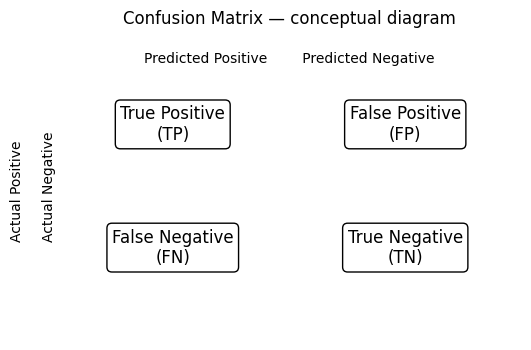

In [7]:
# Draw a labelled confusion matrix for teaching
fig, ax = plt.subplots(figsize=(6,4))
# Draw squares
ax.axis('off')
# Create text boxes
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax.text(0.25, 0.65, 'True Positive\n(TP)', fontsize=12, bbox=props, ha='center')
ax.text(0.75, 0.65, 'False Positive\n(FP)', fontsize=12, bbox=props, ha='center')
ax.text(0.25, 0.25, 'False Negative\n(FN)', fontsize=12, bbox=props, ha='center')
ax.text(0.75, 0.25, 'True Negative\n(TN)', fontsize=12, bbox=props, ha='center')
ax.text(0.5, 0.9, 'Predicted Positive        Predicted Negative', ha='center')
ax.text(-0.1, 0.5, 'Actual Positive\n\nActual Negative', va='center', rotation=90)
plt.title('Confusion Matrix — conceptual diagram')
plt.show()

## Decision boundary visual (PCA 2D) — teaching aid

High-dimensional models are hard to visualize. We'll reduce features to 2D with PCA and plot model boundaries to see how classifiers separate classes.


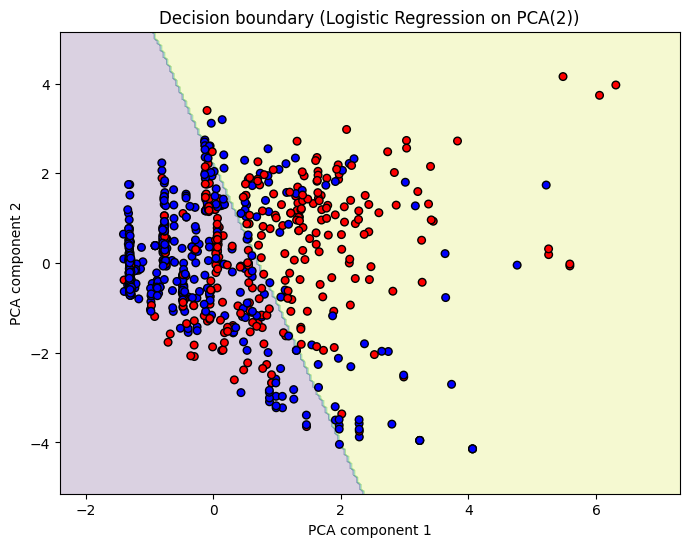

In [8]:
# PCA to 2D for decision boundary visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

# Fit a simple classifier (e.g., logistic regression) on PCA features
lr2 = LogisticRegression(max_iter=1000).fit(X_pca, y)

# Create mesh grid
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='bwr', edgecolor='k', s=30)
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.title('Decision boundary (Logistic Regression on PCA(2))')
plt.show()

This plot shows a **decision boundary** for a machine learning classifier (Logistic Regression) applied to data that's been reduced to two dimensions using **PCA** (Principal Component Analysis).

### What Are You Seeing?

- Each dot is a data point, colored by class—often, for example, red for one outcome (e.g., not survived) and blue for the other (e.g., survived) in Titanic data.
- The background is split into two colored regions by the model’s decision boundary—this is the line where the model “decides” to classify points as one class or the other.
- The X and Y axes are the first two “principal components,” which are combinations of your original features, found by PCA to best capture the spread and separation in the data.


### Why Did We Do This?

- The original data may have many features (age, fare, siblings, etc.), which are hard to visualize.
- PCA reduces these many dimensions down to just two, preserving as much separation as possible.
- Plotting the decision boundary in this 2D space lets us visually see how the classifier splits the data—where its “border” is between classes.


### Significance

- **Conceptual understanding:** Decision boundaries show how a machine learning model distinguishes between groups based on the input data.
- **Diagnostic value:** If the boundary neatly separates the colored points, your model is doing well. If there’s lots of mixing and overlap, your model may need more features, different preprocessing, or be inherently limited.
- **Data reduction insight:** PCA is a powerful tool for simplifying data, which helps you visualize and sometimes improve your models.


### Overall Concept

- **PCA**: Used to reduce high-dimensional data to two “principal components” for easier plotting.
- **Decision boundary**: Shows where the classifier predicts class changes—helpful for understanding and explaining model behavior.
- **Visual evaluation**: Lets you quickly spot how well a model splits up the data and identifies areas where it might make mistakes.

This is a classic and beginner-friendly way to combine dimensionality reduction and classification visualization in machine learning.


## Bias–Variance: learning curves and overfitting demonstration

We plot training and cross-validation scores vs number of training samples (learning curves) and vs model complexity (tree depth) to show under/overfitting.


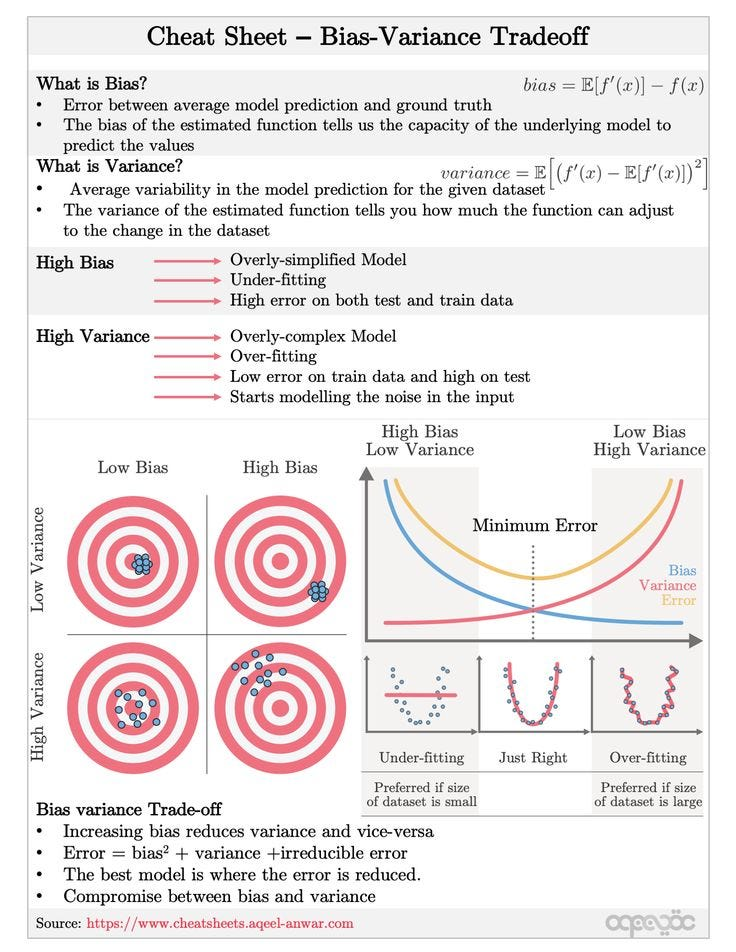

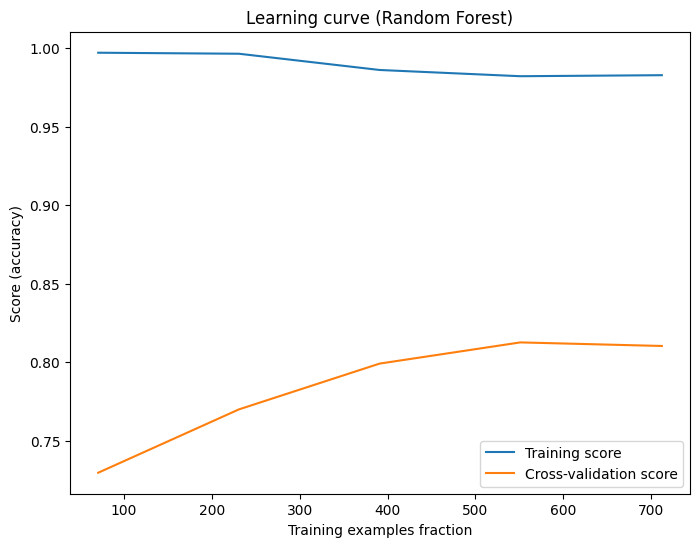

In [9]:
# Learning curve example for RandomForest (using scikit-learn learning_curve)
from sklearn.model_selection import learning_curve
rf = RandomForestClassifier(n_estimators=100, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(rf, StandardScaler().fit_transform(X), y, cv=5, train_sizes=np.linspace(0.1,1.0,5), n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, val_mean, label='Cross-validation score')
plt.xlabel('Training examples fraction')
plt.ylabel('Score (accuracy)')
plt.title('Learning curve (Random Forest)')
plt.legend()
plt.show()

This plot is a **learning curve** for a Random Forest classifier, and it’s a vital diagnostic tool in machine learning.

### What Is Shown?

- **X-axis:** Number (or fraction) of training examples used—moving left to right means the model gets trained on more data.
- **Y-axis:** Score (accuracy), reflecting how often the classifier makes the correct prediction.


### Two Curves:

- **Training score (blue):** Accuracy on the data the model was trained with.
- **Cross-validation score (orange):** Accuracy from held-out (unseen) data, using cross-validation to estimate real-world performance.


### What Does It Mean?

- At the left, the blue line is almost 1.0 (perfect accuracy)—the model fits the small training set very well, often memorizing it (overfitting).
- The orange line (validation accuracy) starts low: with little training data, the model can’t generalize.
- As the training set size increases:
    - **Training accuracy falls slightly:** The model can’t memorize everything, so it’s forced to learn general rules.
    - **Validation accuracy rises:** The model learns more robust patterns and does better on new, unseen data.
- Eventually, both lines plateau—adding more data produces little extra improvement, suggesting you may have reached the limit of what the available features and the model can achieve.


### Why Is This Useful?

- Learning curves help:
    - Spot **overfitting** (when training score is much higher than validation score).
    - Detect **underfitting** (both scores are low).
    - Decide if more training data would help (validation score still rising), or if you should try a bigger/different model or better features (score is flat).
- They’re a core tool for diagnosing training quality and making evidence-based improvements.

In summary: Learning curves show whether your model is learning useful patterns or just memorizing, and help guide next steps in improving data, features, or models for better performance

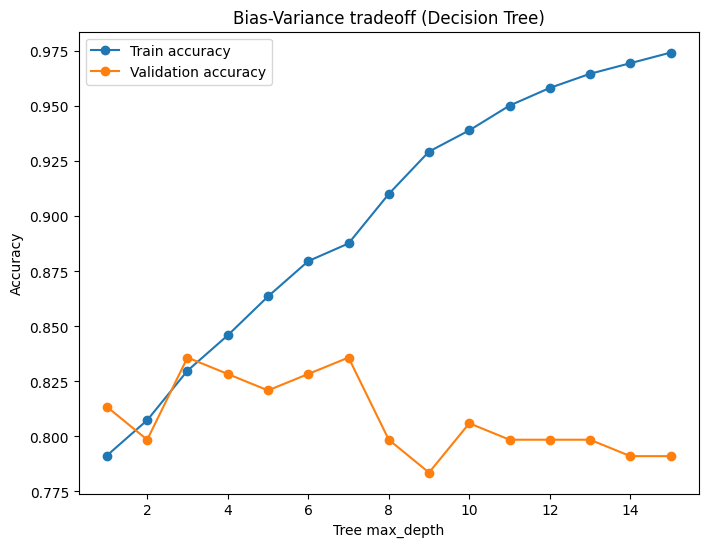

In [10]:
# Accuracy vs model complexity (Decision Tree depth)
train_acc = []
val_acc = []
depths = list(range(1,16))
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_s, y_train)
    train_acc.append(dt.score(X_train_s, y_train))
    val_acc.append(dt.score(X_val_s, y_val))

plt.figure(figsize=(8,6))
plt.plot(depths, train_acc, marker='o', label='Train accuracy')
plt.plot(depths, val_acc, marker='o', label='Validation accuracy')
plt.xlabel('Tree max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance tradeoff (Decision Tree)')
plt.legend()
plt.show()

This plot illustrates the **bias-variance tradeoff** for a decision tree classifier by showing how accuracy changes as the tree's maximum depth increases.

### What Is Shown?

- **X-axis:** The maximum depth allowed in the decision tree (how many times it can split).
- **Y-axis:** Model accuracy.


### Two Curves:

- **Train accuracy (blue):** How well the model does on the data it was trained on.
- **Validation accuracy (orange):** How well the model does on separate "unseen" validation data.


### What Does It Mean?

- When the tree is very shallow (low max_depth), both accuracies are low and similar — this is **high bias** (the model is too simple to capture the real patterns).
- As depth increases, training accuracy goes up steadily (the tree can memorize the training data), but validation accuracy rises only up to a point and then flattens or falls.
- When the tree is very deep (high max_depth), training accuracy nearly reaches 1 (perfect fit) but validation accuracy drops — this is **high variance** or **overfitting** (the model fits "noise" in the training data and can’t generalize).


### Why Is This Significant?

- This plot visually demonstrates the **tradeoff between bias and variance** in model complexity.
- Your goal is to find the "sweet spot" — a max_depth where validation accuracy is highest, before overfitting starts.
- It explains why simply making your model more complex doesn't always lead to better results on new data.

**Summary:**
Use plots like this to tune your model's complexity — too simple underfits, too complex overfits. The "best" model balances low training bias with low validation variance, maximizing performance on unseen data.

## Practical tips, pitfalls, and exercises

- Always stratify splits for classification to maintain class ratios.
- Use pipelines to avoid data leakage.
- For imbalanced data, prefer ROC-AUC and F1 over accuracy.
- Exercise: Try nested cross-validation for model selection and estimation of the generalization score.

**End of supervised learning notebook.**